# outlier removing using z score: 
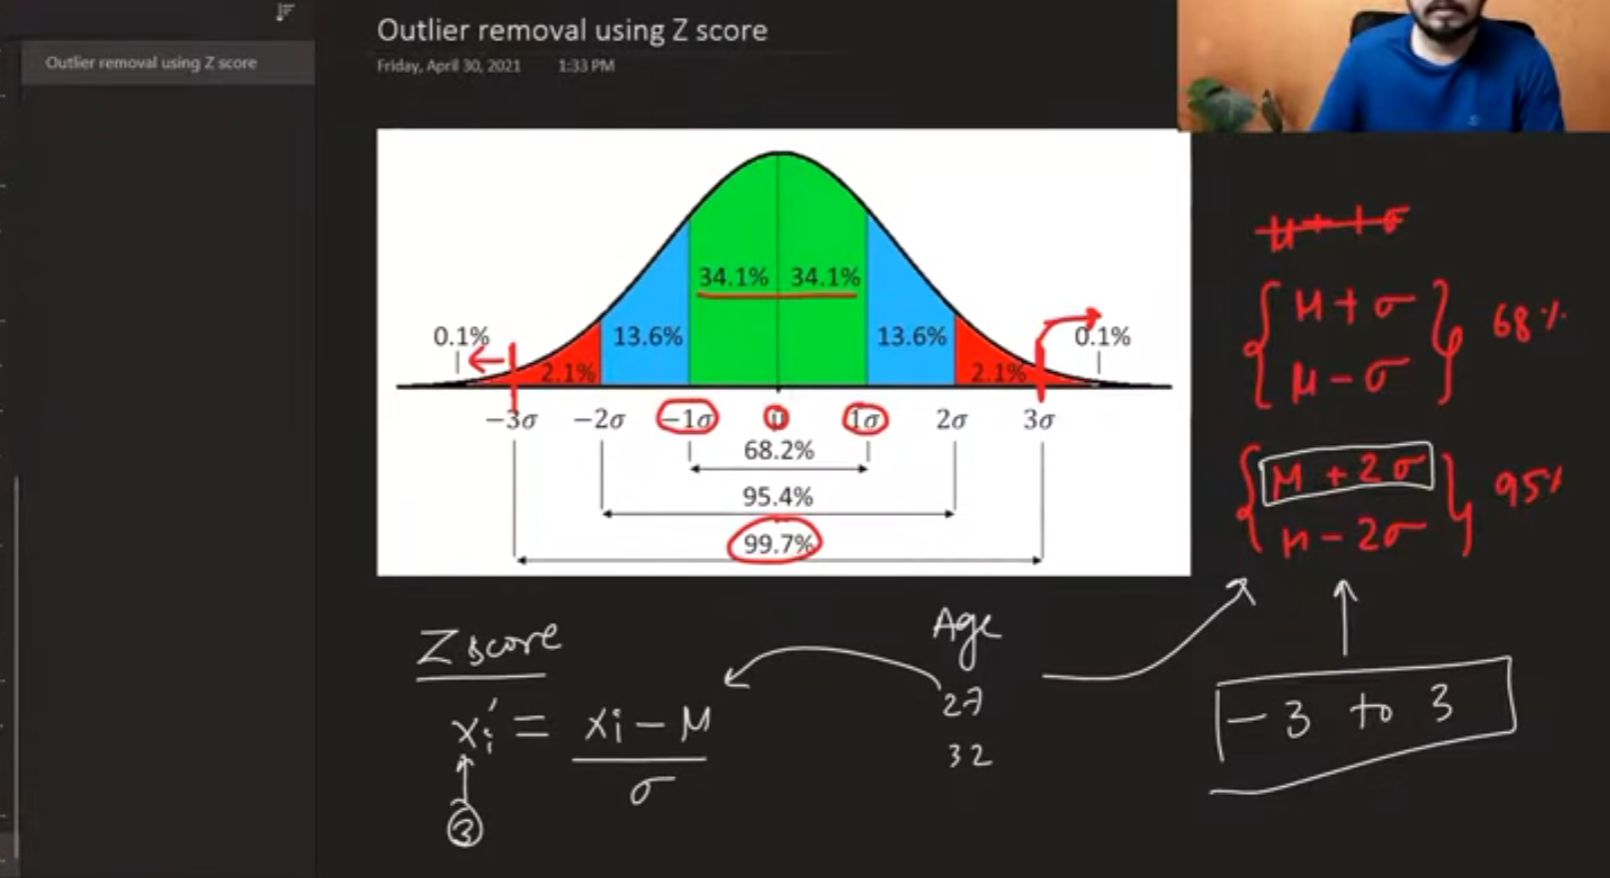


first of all we have to check our column is  normally distributed(close to normal distribution) or not 
if yes then we find range by 
mean + 3 sd and mean - 3 sd

and the rows which are outside of this range are outliers

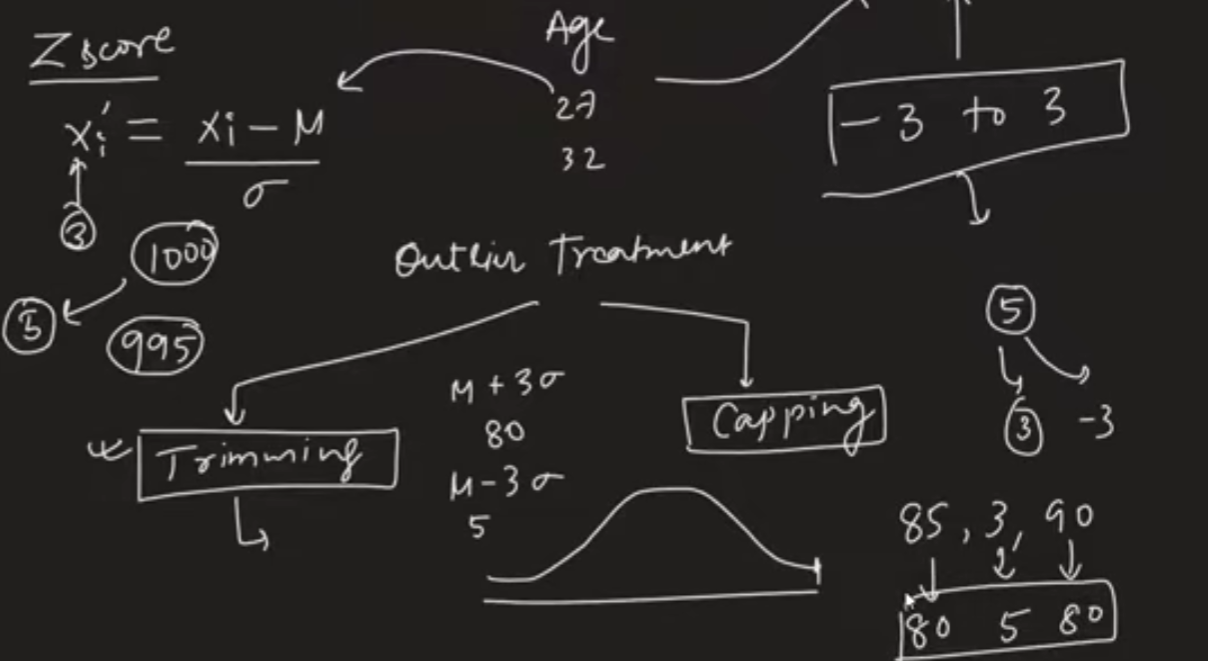

then we remove it by using trimming and capping . 

trimming : we remove completely the row 

by trimming we can lose our significant data  if there are many outliers in our data 

capping : we set max and min limit if something smaller or greater than the limit 
then it will be considered as an outlier

ex: max = 80 and min = 5 if we have 3 values 2,89,90 then the maximum outliers will be converted to maximum range 
wich is 80 and minimum outliers will be converted to minimum range which is 5 
then  our values will be = 5, 80, 80

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('placement.csv')

In [5]:
df.shape

(1000, 3)

In [6]:
df.sample(5)

,cgpa,placement_exam_marks,placed
937,6.42,34.0,0
556,6.70,15.0,1
711,6.97,30.0,1
62,7.61,22.0,0
509,7.83,48.0,0


C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_15888\4089624896.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_15888\4089624896.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


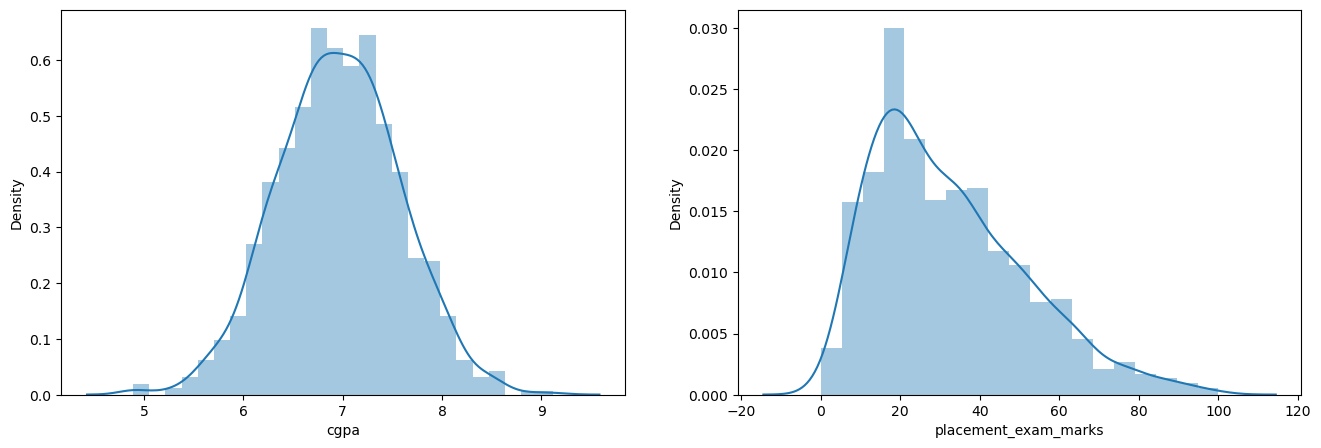

In [10]:
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [11]:
print("Mean value of cgpa", df["cgpa"].mean())
print("Std value of cgpa", df["cgpa"].std())
print("Min value of cgpa", df["cgpa"].min())
print("Max value of cgpa", df["cgpa"].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [12]:
print('highest allowed',df['cgpa'].mean() + 3* df['cgpa'].std())
print('lowest allowed',df['cgpa'].mean() - 3* df['cgpa'].std())

highest allowed 8.808933625397168
lowest allowed 5.113546374602832


In [18]:
# outlier detection
df[(df['cgpa']>8.8)| (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


 # trimming 

In [24]:
# outlier detection
new_df = df[(df['cgpa']<8.8) & (df['cgpa']>5.11)]

In [25]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [26]:
df['cgpa_zScore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [27]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zScore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [30]:
df[(df['cgpa_zScore']>3) | (df['cgpa_zScore'] <-3 )]

,cgpa,placement_exam_marks,placed,cgpa_zScore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


# capping 

In [48]:
upper_limit = df['cgpa'].mean() + 3* df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3* df['cgpa'].std()

In [49]:
print(upper_limit)
print(lower_limit)

8.808933625397168
5.113546374602832


In [54]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit
    ,upper_limit,
    np.where(
        df['cgpa']<lower_limit
        ,lower_limit,
        df['cgpa']
    )
)

In [55]:
df.shape

(1000, 4)

In [56]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64